In [1]:
import pandas as pd
import random

 

### config experiment

In [2]:
import os

working_dir = os.getcwd()
print(working_dir)

parts = working_dir.split("/")

#if parts[-1] == "pipeline":
if parts[-1].startswith("pipeline"): ### BUG SOLVED MAY 2025
    pipeline = working_dir
else:
    pipeline ="/".join(parts[:-1])
print(pipeline)

/home/ematos/phd/pipeline_city/GRAFICOS
/home/ematos/phd/pipeline_city


In [3]:
import sys 
base = pipeline
sys.path.append(base)

from config.configsite import *

#print(f"filesdir = {filesdir}") # new AT april 2025
print(f"pipeline = {pipeline}") # new AT april 2025

pipeline = /home/ematos/phd/pipeline_city/


# ler dados (BIO)

In [4]:
results_flair_dir=pipeline+"PROCESS_TEST_SET_WITH_NER_LLM/"+resultsdir

In [5]:

df = pd.read_csv(results_flair_dir+"test_results_BIO.tsv",sep="\t", quoting=3) 

df

,word,tag
0,Lima,B-CIDADE
1,é,O
2,a,O
3,capital,O
4,do,O
...,...,...
17397,=,O
17398,Não,O
17399,se,O
17400,aplica,O


In [6]:
 
df['tag'] = df['tag'].str.replace(r'^[BI]-', '', regex=True)


In [7]:
df2 = df[df.tag != 'O']
df2.head()

,word,tag
0,Lima,CIDADE
15,metrópole,METROPOLIS
21,Paulo,CIDADE_GRANDE
50,Recife,CIDADE
57,Pernambuco,ESTADO_BRASILEIRO


In [8]:
contagens = df2.value_counts("tag")
c = pd.DataFrame(contagens).reset_index()
c

,tag,count
0,CIDADE,210
1,PAÍS,194
2,ENTIDADE_TERRITORIAL_ARTIFICIAL,143
3,HUMANO,56
4,ESTABELECIMENTO,48
...,...,...
183,VEÍCULO,1
184,WIKIPEDIA,1
185,WIKIDATA,1
186,sup,1


In [9]:
#!pip install seaborn

<Axes: xlabel='count', ylabel='tag'>

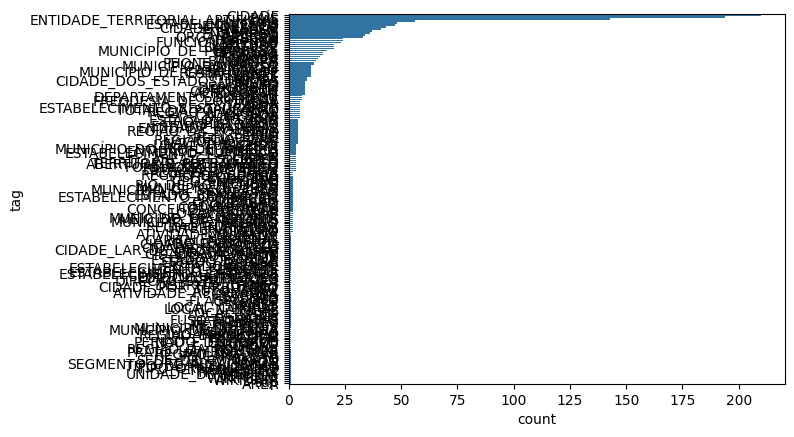

In [10]:
import seaborn as sns
sns.barplot(data  = c,
            y='tag',
            x='count'
           )

In [11]:
aux = df2[df2.tag == "PAÍS"]["word"].unique()
print(aux)

['Brasil' 'Irlanda' 'Itália' 'Índia' 'República' 'Tcheca' 'Cabo' 'Verde'
 'Dominicana' 'Inglaterra' 'Europa' 'Lithuania' 'Maurícias' 'Rajastão'
 'EUA' 'país' 'Maurício' 'Orissa' 'romeno' 'Romeno' 'Madagáscar' 'Reunião'
 'Rodrigues' 'norte' '-' 'americana' 'europeia' 'Equador' 'Chile' 'Puerto'
 'Rico' 'Estados' 'Unidos' 'Romênia' 'Roménia' 'Lituânia' 'inglesas'
 'Rússia' 'Espanha' 'Peru' 'Russa' 'Reino' 'Unido' 'Russo' 'Polônia'
 'Alasca' 'portugueses' 'Romania' 'Maurícia' 'Porto' 'estado' 'Ásia'
 'americanos' 'Italianos' 'Franceses' 'Japoneses' 'Mexicanos'
 'Brasileiros' 'Hungria' 'portorriquenho' 'porto' 'riquenhas' 'mundo'
 'brasileiros' 'Angola' 'Bulgária' 'Transilvânia' 'cirílico' 'Andes'
 'Caribe' 'peruano' 'peruanos' 'brasileiro']


In [12]:
def counts(df2, ent):
    aux = df2[df2.tag == ent]["word"].unique()
    #print(aux)

    return (list(aux))

In [13]:
r =counts (df2, "PAÍS")
print(r)

['Brasil', 'Irlanda', 'Itália', 'Índia', 'República', 'Tcheca', 'Cabo', 'Verde', 'Dominicana', 'Inglaterra', 'Europa', 'Lithuania', 'Maurícias', 'Rajastão', 'EUA', 'país', 'Maurício', 'Orissa', 'romeno', 'Romeno', 'Madagáscar', 'Reunião', 'Rodrigues', 'norte', '-', 'americana', 'europeia', 'Equador', 'Chile', 'Puerto', 'Rico', 'Estados', 'Unidos', 'Romênia', 'Roménia', 'Lituânia', 'inglesas', 'Rússia', 'Espanha', 'Peru', 'Russa', 'Reino', 'Unido', 'Russo', 'Polônia', 'Alasca', 'portugueses', 'Romania', 'Maurícia', 'Porto', 'estado', 'Ásia', 'americanos', 'Italianos', 'Franceses', 'Japoneses', 'Mexicanos', 'Brasileiros', 'Hungria', 'portorriquenho', 'porto', 'riquenhas', 'mundo', 'brasileiros', 'Angola', 'Bulgária', 'Transilvânia', 'cirílico', 'Andes', 'Caribe', 'peruano', 'peruanos', 'brasileiro']


In [14]:
r =counts (df2, "CIDADE")
print(r)

['Lima', 'Recife', 'Praha', 'Piracicaba', 'Praia', 'Port', 'cidade', 'Londres', 'Dublin', 'Limerick', 'Nova', 'York', 'Olinda', 'Jaboatão', 'dos', 'Guararapes', 'Praga', 'Budapeste', 'Cracóvia', 'São', 'Paulo', 'Lisboa', 'Punta', 'Cana', 'Venezuela', 'Rio', 'de', 'Janeiro', 'Louis', 'London', 'Puri', 'Callao', 'Bubaneshwar', 'Jagannatja', 'Calcutá', 'Cidade', 'da', 'Moscou', 'Machu', 'Picchu', 'Londrina', 'Euston', 'Independência', 'Kaliningrado', 'Kiev', 'Coqueiral', 'Camaragibe', 'Vilnius', 'Riga', 'Kensington', 'Chelsea', 'Kaunas', 'Vilnus', 'Ponce', 'Aguadilla', 'Cambridge', 'Fajardo', 'Vieques', 'Culebra', 'San', 'Juan', 'Porto', 'Itamaracá', 'Ponces', 'é', 'cidades', 'Las', 'Marias', 'Gatwick', 'Heathrow', 'Alegre', 'El', 'Bucareste', 'Sofia', 'Federais', 'M', 'Wien', 'Martín', 'Pisco', 'Arad', 'Varsóvia', 'Berlim', 'Paris', 'Moscovo', 'Cusco', 'Puno', 'Arequipa', 'Vladivostok', 'Petersburgo', 'Can']


In [15]:
entidades = df2.tag.unique()
entidades

array(['CIDADE', 'METROPOLIS', 'CIDADE_GRANDE', 'ESTADO_BRASILEIRO',
       'PAÍS', 'REGIÃO_BRASILEIRA', 'HUMANO',
       'ENTIDADE_TERRITORIAL_ARTIFICIAL', 'REGIÃO_DA_ITÁLIA',
       'ESTADO_DA_INDIA', 'CONTINENTE', 'MUNICÍPIO_DO_BRASIL', 'REGIÃO',
       'ESTADO_DA_USA', 'IMAGEM', 'CAPITAL', 'MUNICÍPIO_DE_PORTUGAL',
       'BANDEIRA', 'ESTABELECIMENTO', 'CASTELO', 'NUMERO', 'FLAGE_LAND',
       'AEROPORTO', 'ENDEREÇO', 'REVISTA', 'CIDADE_RIMINI', 'LOCALIDADE',
       'FORMA_DE_GOVERNO', 'HORÁRIO', 'MOEDA', 'TRANSPORTE', 'VEÍCULO',
       'UNIDADE_DE_MEDIDA', 'sup', 'TEMPLO', 'NUMÉRICO', 'AREA',
       'ENTIDADE_NÚMERICA', 'TOTAL_DA_POPULAÇÃO', 'POPULAÇÃO',
       'CIDADE_DOS_ESTADOS_UNIDOS', 'IDIOMA', 'SANTO', 'LIVRO',
       'RELIGIÃO', 'TIPO_DE_PUBLICAÇÃO', 'LÍNGUA', 'ESTAÇÃO_DO_ANO',
       'NAO_E_ENTIDADE', 'ENTIDADE_NATURAL', 'PRODUTO', 'TENSÃO',
       'FREQUÊNCIA', 'CONCEITO_ABSTRATO', 'TELEFONE', 'LOCAL_TURÍSTICO',
       'ORGANIZAÇÃO', 'PADRÃO', 'LOCAL_CABO', 'LOCAL_CURADO',

In [16]:
num_difs =[]
ents = []
for e in entidades:
    r =counts (df2, e)
    r2 = len(r)
    num_difs.append(r2)
    ents.append(e)

print(num_difs)
print(ents)    

[90, 1, 23, 2, 73, 1, 51, 37, 3, 1, 4, 8, 10, 1, 25, 1, 17, 11, 45, 1, 6, 1, 5, 27, 22, 1, 2, 2, 12, 7, 1, 1, 1, 1, 2, 4, 4, 3, 4, 7, 5, 11, 1, 1, 12, 1, 5, 3, 1, 4, 7, 1, 2, 1, 17, 2, 30, 2, 1, 1, 2, 1, 5, 5, 2, 1, 1, 1, 4, 1, 1, 3, 1, 4, 2, 1, 1, 1, 5, 1, 30, 7, 4, 17, 4, 7, 1, 6, 2, 2, 2, 2, 1, 1, 1, 10, 1, 3, 1, 3, 1, 1, 1, 1, 1, 2, 1, 3, 2, 2, 1, 3, 1, 1, 1, 1, 9, 1, 2, 6, 12, 2, 6, 2, 2, 1, 3, 1, 1, 2, 1, 2, 3, 2, 1, 1, 1, 1, 10, 1, 5, 3, 1, 1, 3, 1, 7, 1, 1, 3, 1, 1, 1, 1, 2, 1, 1, 3, 2, 8, 8, 1, 1, 1, 2, 1, 2, 5, 2, 1, 2, 2, 2, 3, 2, 8, 1, 1, 1, 1, 1, 1, 3, 14, 4, 1, 1, 1]
['CIDADE', 'METROPOLIS', 'CIDADE_GRANDE', 'ESTADO_BRASILEIRO', 'PAÍS', 'REGIÃO_BRASILEIRA', 'HUMANO', 'ENTIDADE_TERRITORIAL_ARTIFICIAL', 'REGIÃO_DA_ITÁLIA', 'ESTADO_DA_INDIA', 'CONTINENTE', 'MUNICÍPIO_DO_BRASIL', 'REGIÃO', 'ESTADO_DA_USA', 'IMAGEM', 'CAPITAL', 'MUNICÍPIO_DE_PORTUGAL', 'BANDEIRA', 'ESTABELECIMENTO', 'CASTELO', 'NUMERO', 'FLAGE_LAND', 'AEROPORTO', 'ENDEREÇO', 'REVISTA', 'CIDADE_RIMINI', 'LOCALI

In [17]:
c2 = pd.DataFrame({'entity':ents, 'num different words':num_difs})

## gráfico com num de differente words per entity

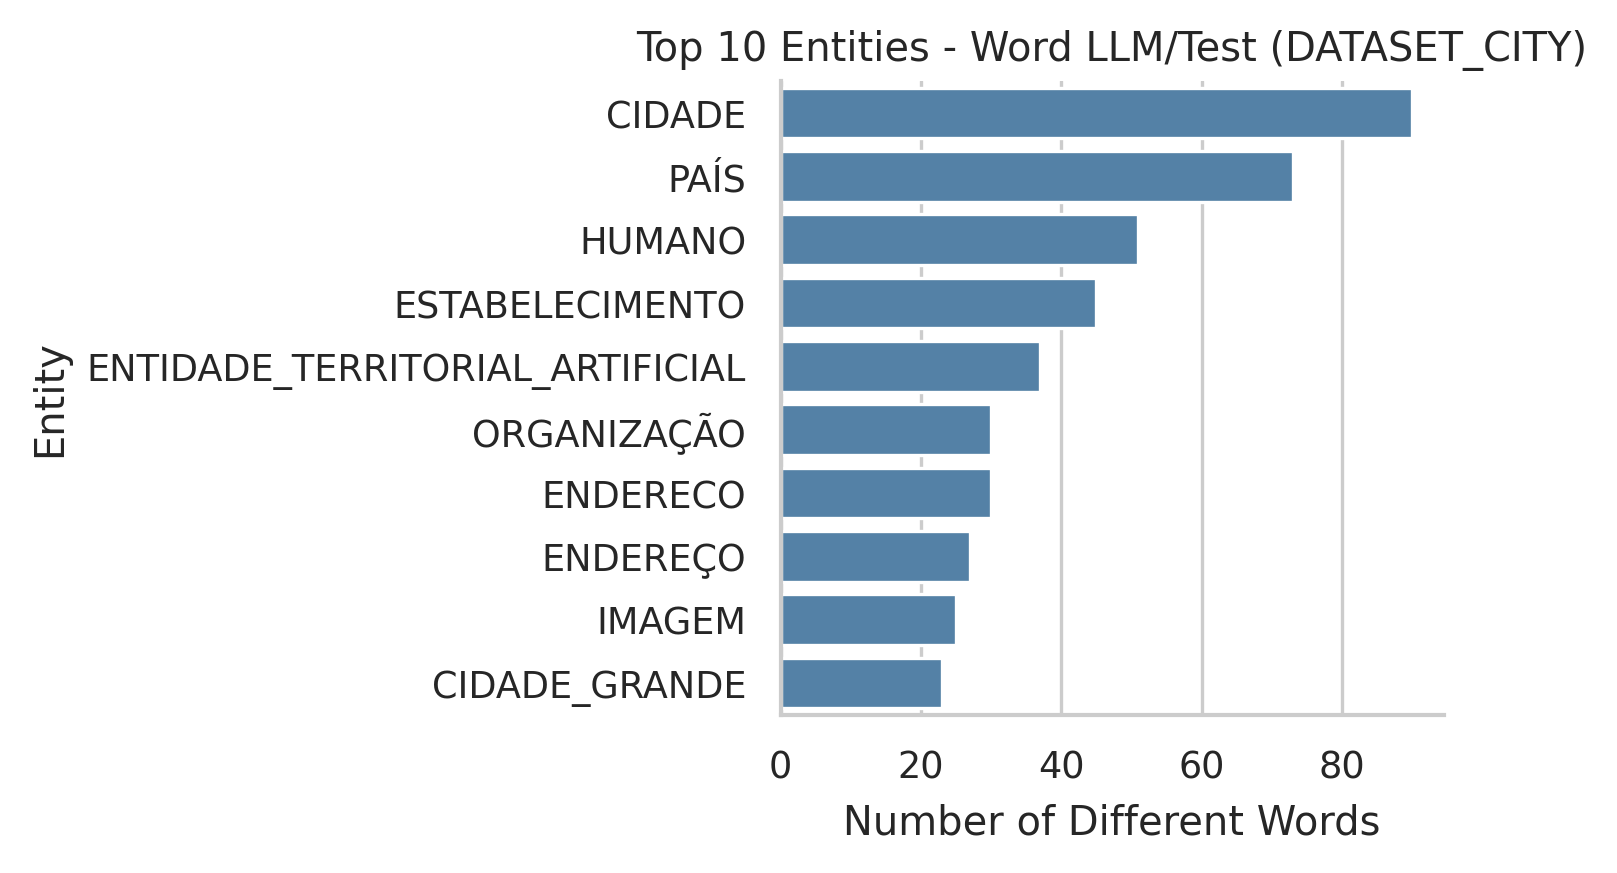

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtra e ordena os TOP 10
top10 = c2.sort_values(by='num different words', ascending=False).head(10)

# Configuração visual compacta
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "font.family": "DejaVu Sans",
    "figure.dpi": 300
})

sns.set_theme(style="whitegrid", context="paper")

# Criação do gráfico
plt.figure(figsize=(5, 3))
ax = sns.barplot(
    data=top10,
    y='entity',
    x='num different words',
    color="steelblue"
)

# Título e labels
ax.set_title(f"Top 10 Entities - Word LLM/Test ({dataset})", pad=5)
ax.set_xlabel("Number of Different Words")
ax.set_ylabel("Entity")

sns.despine()
plt.tight_layout()

# Salva
plt.savefig(f"words_top10_LLM_Test_{dataset}.png", dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='num different words', ylabel='entity'>

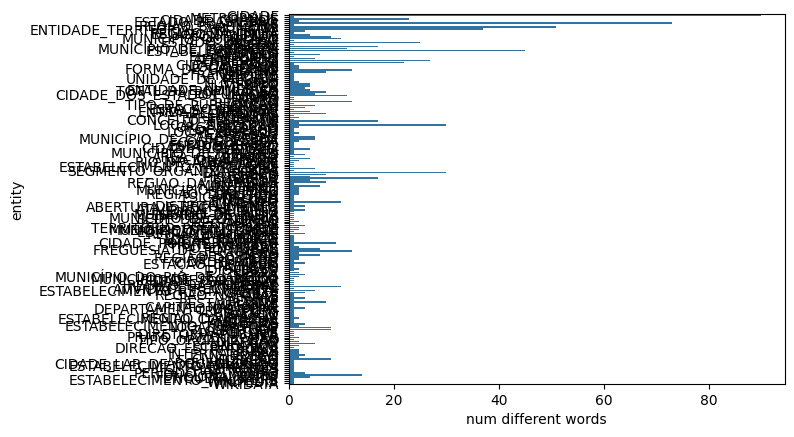

In [18]:
import seaborn as sns
sns.barplot(data  = c2,
            y='entity',
            x='num different words'
           )

In [21]:
r =counts (df2, "CIDADE_GRANDE")
print(r)

['Paulo', 'Piracicaba', 'Jaipur', 'Udaipur', 'Agra', 'cidade', 'São', 'Campinas', 'Praga', 'Recife', 'Londres', 'Viracopos', 'Porto', 'Rico', 'Vilnius', 'San', 'Juan', 'Rio', 'Piedras', 'Moscou', 'Petersburgo', 'Iquitos', 'Manaus']


In [22]:
r =counts (df2, "RIO")
print(r)

['Danúbio', 'Solimões', 'Amazonas']
